In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from funcs import plot_sensors

In [16]:
df = pd.read_csv(r"C:\Users\User\Desktop\water\data\water_stats.csv")
regions = {976 : 'Ακταίο', 977: 'Ψαθόπυργος',978: 'Αραχωβίτικα', 979: 'Άγιος Βασίλης',980:'Ρίο',981: 'Καστελλόκαμπος', 982: 'Δάφνες',983: 'Πλάζ', 984:'Ροιτικά'}

df['location'] = df['sensor_id'].map(regions)

df['date_insert'] = pd.to_datetime(df['date_insert'])

In [22]:
metrics = []
for i in range(9,len(df.columns)-1):
    metrics.append(df.columns[i])
metrics

['wtempV_°C',
 'conductivity_of_solution_ mS_cm',
 'oxidation_reduction_potential_ mV',
 'total_suspended_solids_mg_L',
 'turbidity_NTU',
 'dissolved_oxygen_concentration _ppm',
 'dissolved_oxygen_concentration_mg_L',
 'oxygen_saturation_%',
 'salinity_ppt',
 'dissolved_solids _ppm']

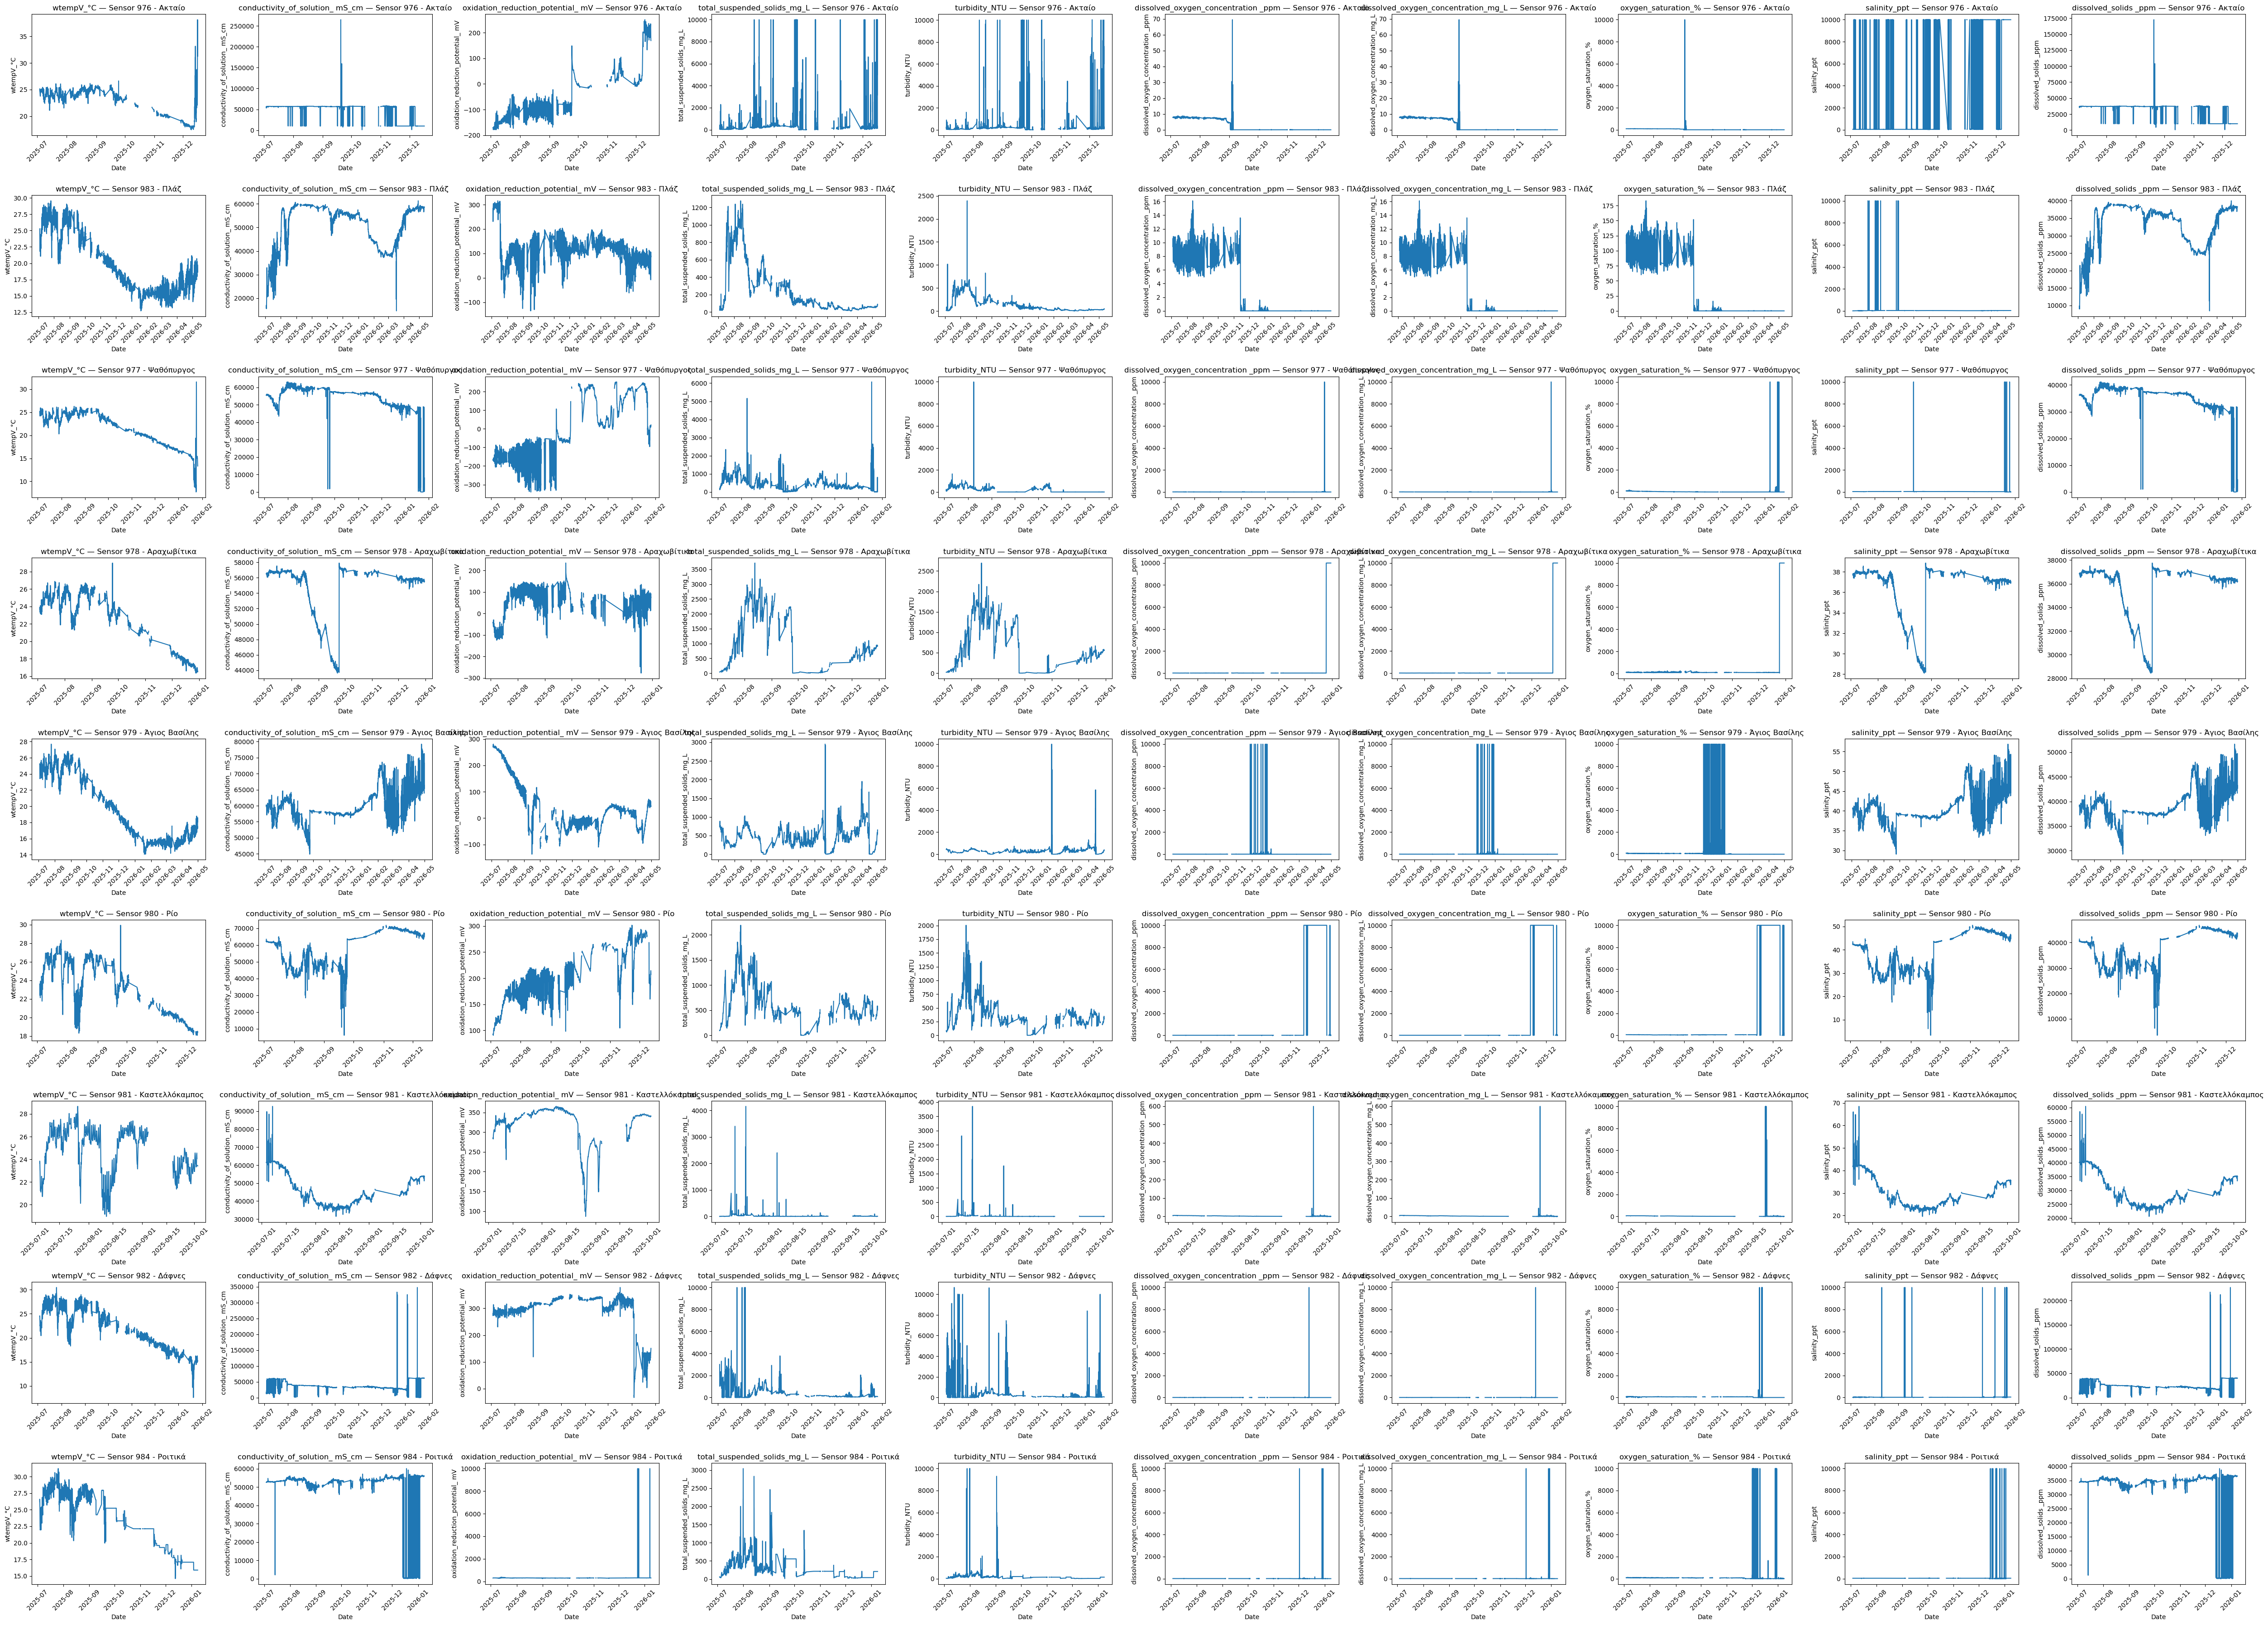

In [23]:
plot_sensors(list(df['sensor_id'].unique()),metrics,df)

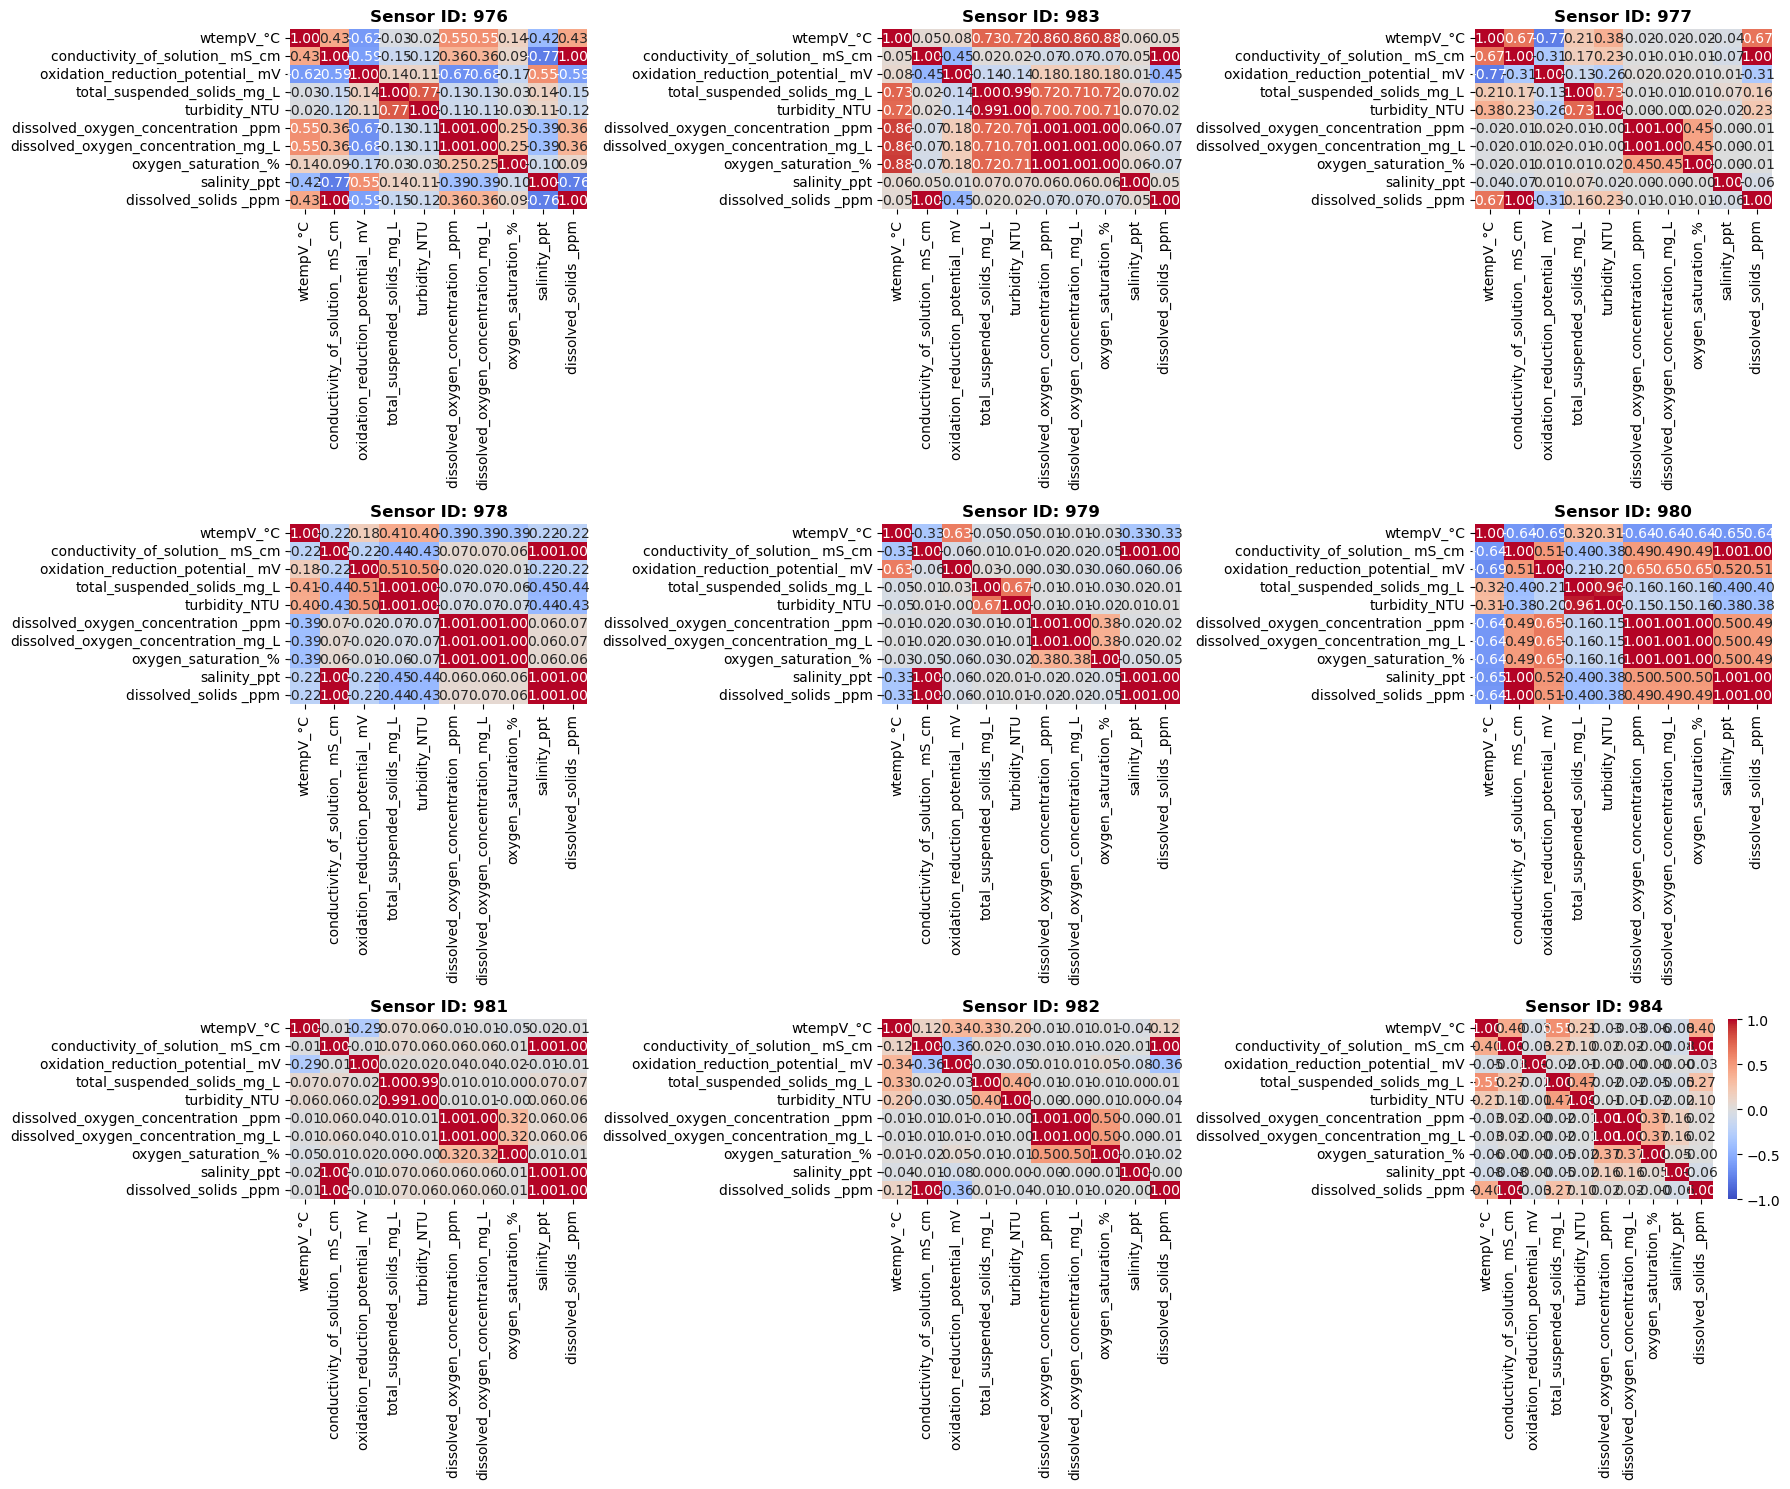

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Get unique sensor IDs
sensors = df['sensor_id'].unique()

for i, sensor_id in enumerate(sensors):
    sensor_df = df[df['sensor_id'] == sensor_id]
    corr = sensor_df[metrics].corr()
    
    sns.heatmap(
        corr, 
        annot=True, 
        fmt='.2f', 
        cmap='coolwarm', 
        vmin=-1, 
        vmax=1, 
        ax=axes[i],
        cbar=(i == 8) # Show colorbar only on the last plot to save space
    )
    axes[i].set_title(f'Sensor ID: {sensor_id}', fontweight='bold')

plt.tight_layout()
plt.show()